# NHS A&E Exploratory Data Analysis (EDA) — From Prepared data to Analyse different pattern

**Project:** AI-Driven Operational Decision Support in NHS Emergency Care

This notebook converts the attendances and performance **numbers** into **the broader picture**


In [1]:
# install python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# setup and load the data
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("Dataset/02_clean_Monthly_AE_data.csv", parse_dates=["Month"])
print("Shape:", df.shape)
df.head()

Shape: (191, 25)


,Month,Year,TotalAttendances,MajorAE_Attendances,SingleSpecialty_Attendances,MinorInjuryUnit_Attendances,TotalAdmissions,Breach12hr,PercentWithin4hrs,MajorInjuryPerformancePct,...,SingleSpecialty_SharePct,MinorInjuryUnit_SharePct,Season,SeasonalBaselineAvg,RiskFlag,MonthSin,MonthCos,MajorShare_x_Winter,Attendances_Lag1,Attendances_RollingMean3
0,2010-08-01,2010,1.752381e+06,1.138652e+06,54371.000000,559358.000000,425702.000000,1.0,NaN,NaN,...,3.10,31.92,Summer,NaN,N/A - not enough prior years yet,-8.660254e-01,-5.000000e-01,0.00,NaN,NaN
1,2010-09-01,2010,1.756268e+06,1.150728e+06,55181.000000,550359.000000,424900.000000,0.0,NaN,NaN,...,3.14,31.34,Autumn,NaN,N/A - not enough prior years yet,-1.000000e+00,-1.836970e-16,0.00,1.752381e+06,NaN
2,2010-10-01,2010,1.801348e+06,1.163143e+06,54961.000000,583244.000000,436215.000000,0.0,NaN,NaN,...,3.05,32.38,Autumn,NaN,N/A - not enough prior years yet,-8.660254e-01,5.000000e-01,0.00,1.756268e+06,1.769999e+06
3,2010-11-01,2010,1.651027e+06,1.111295e+06,53727.428571,486005.428571,429099.000000,2.0,97.2,95.9,...,3.25,29.44,Autumn,NaN,N/A - not enough prior years yet,-5.000000e-01,8.660254e-01,0.00,1.801348e+06,1.736214e+06
4,2010-12-01,2010,1.737741e+06,1.159204e+06,45536.428571,533000.857143,452728.714286,15.0,94.8,92.4,...,2.62,30.67,Winter,NaN,N/A - not enough prior years yet,-2.449294e-16,1.000000e+00,66.71,1.651027e+06,1.730039e+06


In [3]:
# Summary statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Month,191,2018-07-01 19:21:02.827225088,2010-08-01 00:00:00,2014-07-16 12:00:00,2018-07-01 00:00:00,2022-06-16 00:00:00,2026-06-01 00:00:00,NaN
Year,191.0,2018.041885,2010.0,2014.0,2018.0,2022.0,2026.0,4.624685
TotalAttendances,191.0,1976864.986537,916575.0,1831862.357143,1968338.0,2164630.0,2457398.0,245474.519286
MajorAE_Attendances,191.0,1271982.743455,689720.0,1199983.214286,1269088.0,1369188.5,1493345.0,124317.571152
SingleSpecialty_Attendances,191.0,47590.049364,19726.0,44112.0,49458.0,52253.428571,58574.285714,6860.536931
MinorInjuryUnit_Attendances,191.0,657292.193717,207129.0,580945.785714,639053.0,744543.5,911233.0,123054.734973
TotalAdmissions,191.0,488472.376963,326581.0,449942.357143,490221.0,528868.0,567456.0,46341.038102
Breach12hr,191.0,11720.193717,0.0,28.571429,335.0,23787.5,71517.0,18848.549177
PercentWithin4hrs,188.0,85.387234,65.2,75.075,87.55,94.3,97.6,9.277409
MajorInjuryPerformancePct,188.0,77.915426,49.6,61.625,81.4,91.4,96.4,14.086411


## Attendances over time, against the seasonal baseline

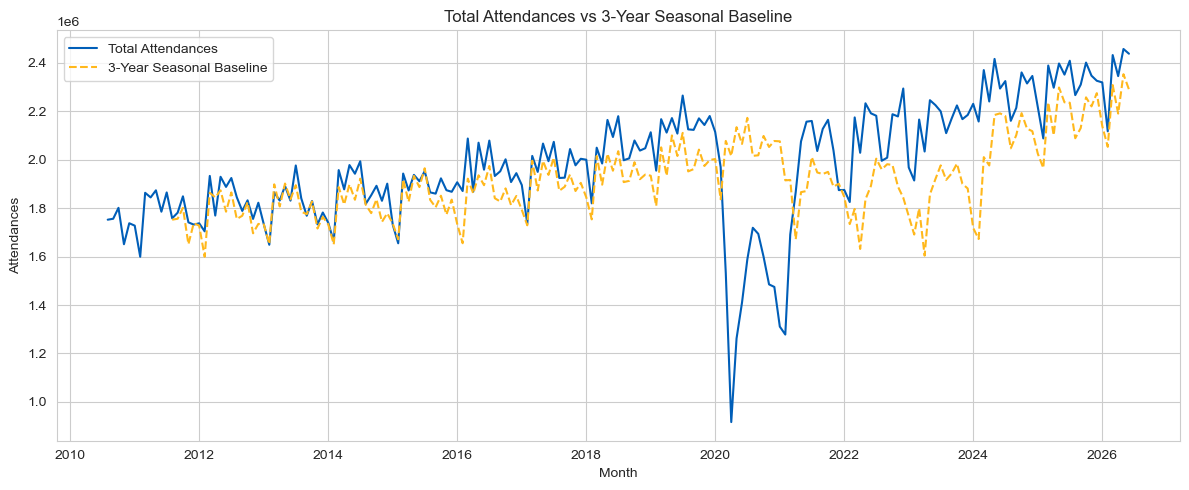

In [5]:
# attendances overtime, against baseline
plt.figure(figsize=(12, 5))
plt.plot(df["Month"], df["TotalAttendances"], label="Total Attendances", color="#005EB8", linewidth=1.5)
plt.plot(df["Month"], df["SeasonalBaselineAvg"], label="3-Year Seasonal Baseline", color="#FFB81C", linewidth=1.5, linestyle="--")
plt.title("Total Attendances vs 3-Year Seasonal Baseline")
plt.xlabel("Month")
plt.ylabel("Attendances")
plt.legend()
plt.tight_layout()
plt.show()

## Seasonal Performance

C:\Users\hp\AppData\Local\Temp\ipykernel_13756\1823237903.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="PercentWithin4hrs", order=season_order, palette=["#003087","#41B6E6","#FFB81C","#78BE20"])


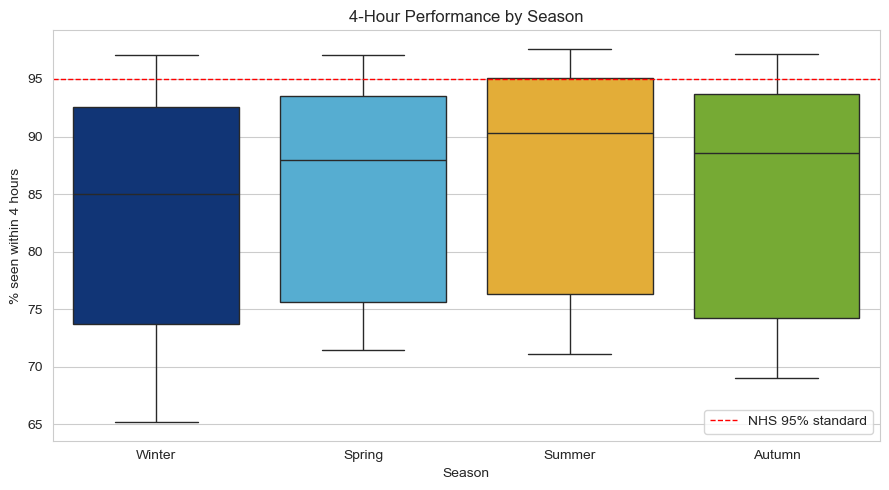

        mean  median  std
Season                   
Winter  83.7    85.0  9.4
Spring  86.0    87.9  8.8
Summer  86.7    90.3  9.2
Autumn  85.2    88.6  9.8


In [6]:
# seasonal performance
plt.figure(figsize=(9, 5))
season_order = ["Winter", "Spring", "Summer", "Autumn"]
sns.boxplot(data=df, x="Season", y="PercentWithin4hrs", order=season_order, palette=["#003087","#41B6E6","#FFB81C","#78BE20"])
plt.axhline(95, color="red", linestyle="--", linewidth=1, label="NHS 95% standard")
plt.title("4-Hour Performance by Season")
plt.ylabel("% seen within 4 hours")
plt.legend()
plt.tight_layout()
plt.show()

print(df.groupby("Season")["PercentWithin4hrs"].agg(["mean","median","std"]).reindex(season_order).round(1))

## MajorInjury vs SingleSpeciality vs MinorInjury Performance

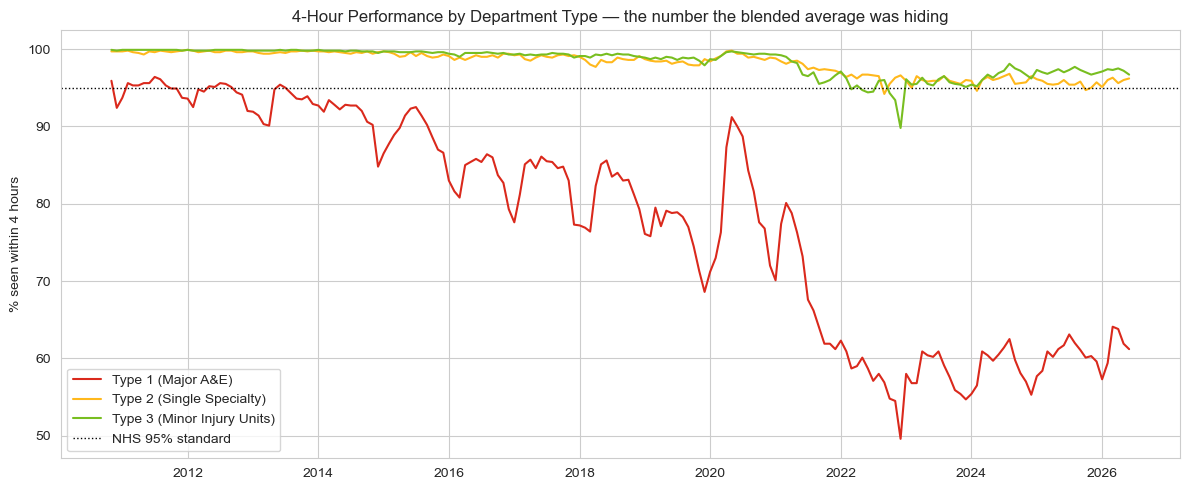

Last 6 months:
     Month  MajorInjuryPerformancePct  SingleSpecialityPerformancePct  MinorInjuryPerformancePct
2026-01-01                       57.3                            95.1                       97.1
2026-02-01                       59.4                            96.0                       97.4
2026-03-01                       64.1                            96.3                       97.3
2026-04-01                       63.8                            95.6                       97.5
2026-05-01                       61.9                            96.0                       97.2
2026-06-01                       61.2                            96.2                       96.7


In [7]:
# 4 hours performance by department type
plt.figure(figsize=(12, 5))
plt.plot(df["Month"], df["MajorInjuryPerformancePct"], label="Type 1 (Major A&E)", color="#DA291C", linewidth=1.5)
plt.plot(df["Month"], df["SingleSpecialityPerformancePct"], label="Type 2 (Single Specialty)", color="#FFB81C", linewidth=1.5)
plt.plot(df["Month"], df["MinorInjuryPerformancePct"], label="Type 3 (Minor Injury Units)", color="#78BE20", linewidth=1.5)
plt.axhline(95, color="black", linestyle=":", linewidth=1, label="NHS 95% standard")
plt.title("4-Hour Performance by Department Type — the number the blended average was hiding")
plt.ylabel("% seen within 4 hours")
plt.legend()
plt.tight_layout()
plt.show()

recent = df.tail(6)[["Month","MajorInjuryPerformancePct","SingleSpecialityPerformancePct","MinorInjuryPerformancePct"]]
print("Last 6 months:")
print(recent.to_string(index=False))

## The 12-hour breach rate over time

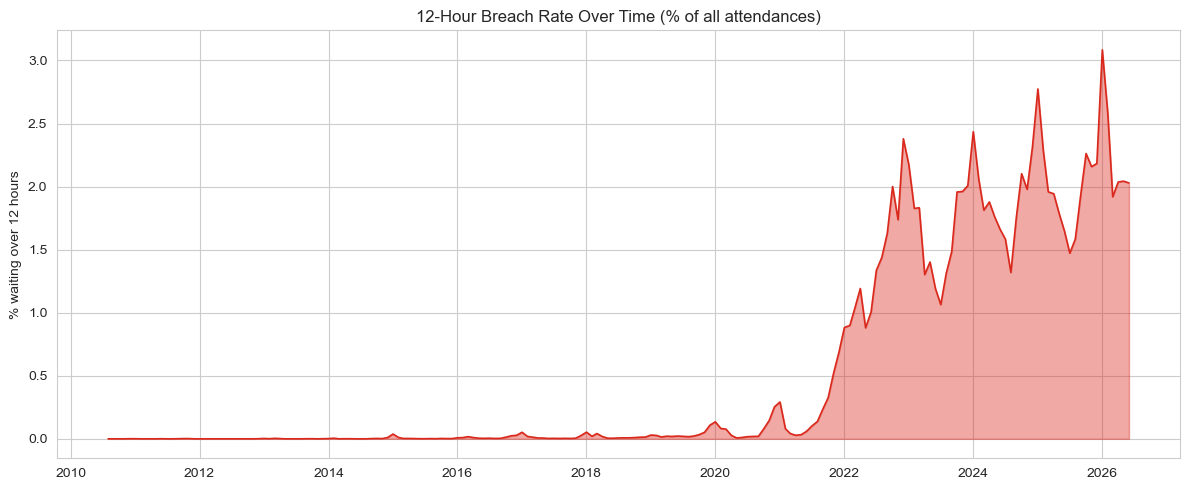

Peak: 3.08% in January 2026
Most recent: 2.03% in June 2026


In [8]:
# 12-hr breach rate over time
plt.figure(figsize=(12, 5))
plt.fill_between(df["Month"], df["Breach12hrRate"], color="#DA291C", alpha=0.4)
plt.plot(df["Month"], df["Breach12hrRate"], color="#DA291C", linewidth=1.2)
plt.title("12-Hour Breach Rate Over Time (% of all attendances)")
plt.ylabel("% waiting over 12 hours")
plt.tight_layout()
plt.show()

peak = df.loc[df["Breach12hrRate"].idxmax()]
print(f"Peak: {peak['Breach12hrRate']:.2f}% in {peak['Month'].strftime('%B %Y')}")
print(f"Most recent: {df['Breach12hrRate'].iloc[-1]:.2f}% in {df['Month'].iloc[-1].strftime('%B %Y')}")

## Attendance Volume vs Admission Rate

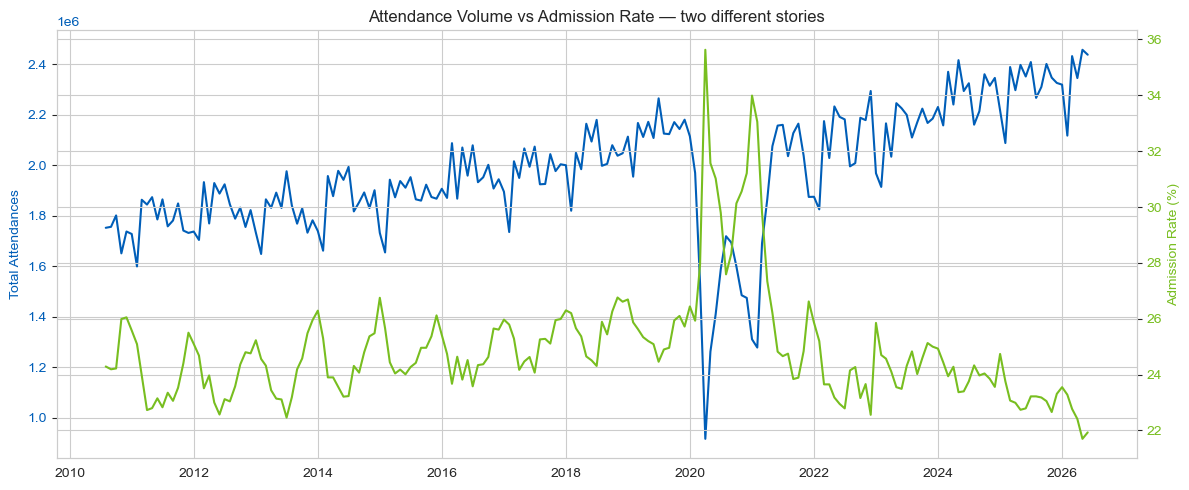

Correlation between TotalAttendances and AdmissionRate: -0.673


In [9]:
# Attendance volume vs admission rate
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df["Month"], df["TotalAttendances"], color="#005EB8", label="Total Attendances")
ax1.set_ylabel("Total Attendances", color="#005EB8")
ax1.tick_params(axis="y", labelcolor="#005EB8")

ax2 = ax1.twinx()
ax2.plot(df["Month"], df["AdmissionRate"], color="#78BE20", label="Admission Rate (%)")
ax2.set_ylabel("Admission Rate (%)", color="#78BE20")
ax2.tick_params(axis="y", labelcolor="#78BE20")

plt.title("Attendance Volume vs Admission Rate — two different stories")
fig.tight_layout()
plt.show()

print("Correlation between TotalAttendances and AdmissionRate:", 
      round(df["TotalAttendances"].corr(df["AdmissionRate"]), 3))

## Correlation matrix

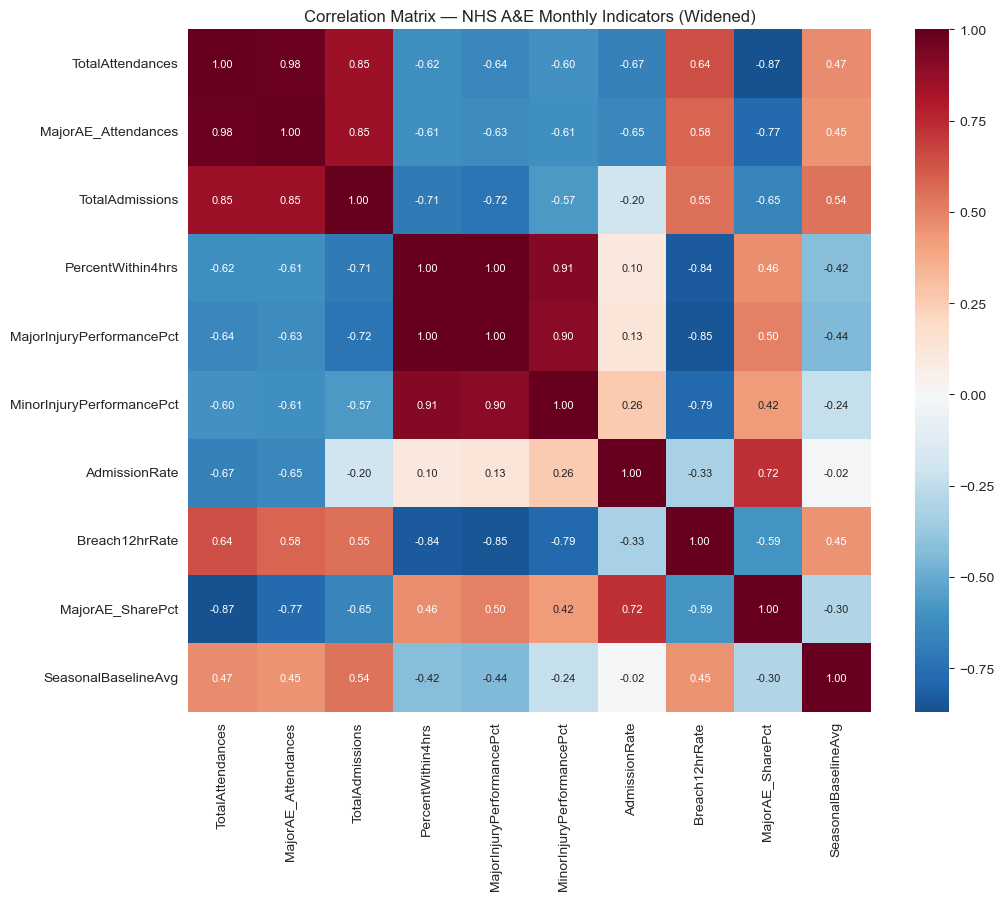

In [10]:
# correlation matrix
numeric_cols = [
    "TotalAttendances", "MajorAE_Attendances", "TotalAdmissions",
    "PercentWithin4hrs", "MajorInjuryPerformancePct", "MinorInjuryPerformancePct",
    "AdmissionRate", "Breach12hrRate", "MajorAE_SharePct", "SeasonalBaselineAvg",
]

import os
os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(11, 9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", annot_kws={"size": 8}, square=True)
plt.title("Correlation Matrix — NHS A&E Monthly Indicators (Widened)")
plt.tight_layout()
plt.savefig("outputs/correlation_matrix.png", dpi=200)
plt.show()

## How balanced is the Risk Flag?

C:\Users\hp\AppData\Local\Temp\ipykernel_13756\1608252380.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#78BE20","#FFB81C","#DA291C"])


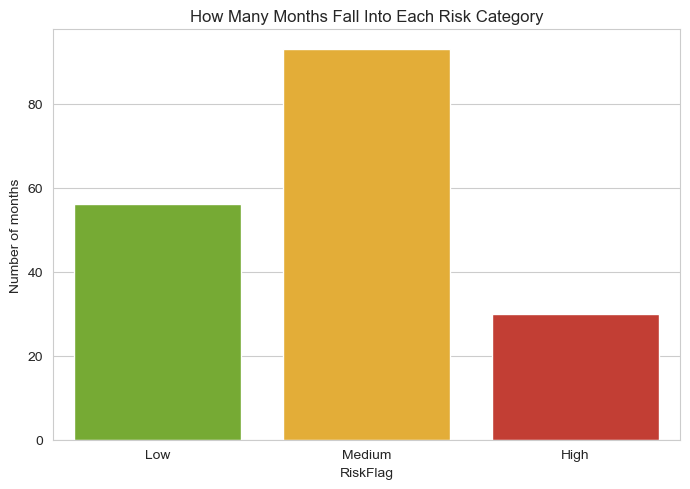

RiskFlag
Low       56
Medium    93
High      30
Name: count, dtype: int64

Medium months outnumber High months by 3.1x — a real imbalance worth accounting for.


In [11]:
# Risk category by total month
counts = df[df["RiskFlag"] != "N/A - not enough prior years yet"]["RiskFlag"].value_counts().reindex(["Low","Medium","High"])

plt.figure(figsize=(7, 5))
sns.barplot(x=counts.index, y=counts.values, palette=["#78BE20","#FFB81C","#DA291C"])
plt.title("How Many Months Fall Into Each Risk Category")
plt.ylabel("Number of months")
plt.tight_layout()
plt.show()

print(counts)
print(f"\nMedium months outnumber High months by {counts['Medium']/counts['High']:.1f}x — a real imbalance worth accounting for.")

## KEY FINDINGS - SUMMARY

In [12]:
# Summary
winter_perf = df[df["Season"]=="Winter"]["PercentWithin4hrs"].mean()
summer_perf = df[df["Season"]=="Summer"]["PercentWithin4hrs"].mean()
type1_recent = df["MajorInjuryPerformancePct"].tail(6).mean()
type3_recent = df["MinorInjuryPerformancePct"].tail(6).mean()
breach_recent = df["Breach12hrRate"].tail(6).mean()
breach_peak = df["Breach12hrRate"].max()
admission_recent = df["AdmissionRate"].tail(12).mean()

print("KEY FINDINGS FOR YOUR SUPERVISOR MEETING")
print("=" * 55)
print(f"1. Winter 4-hour performance averages {winter_perf:.1f}%, vs {summer_perf:.1f}% in Summer —")
print(f"   the worst performance coincides with lower attendance volume, not higher.")
print(f"2. Major A&E (Type 1) performance has averaged {type1_recent:.1f}% within 4 hours over")
print(f"   the last 6 months, vs {type3_recent:.1f}% for Minor Injury Units (Type 3) — a gap")
print(f"   completely hidden by the single blended PercentWithin4hrs figure.")
print(f"3. The 12-hour breach rate has averaged {breach_recent:.2f}% of attendances over the last")
print(f"   6 months, peaking at {breach_peak:.2f}% — a nationally reported crisis indicator.")
print(f"4. Around {admission_recent:.1f}% of all A&E attendances over the last year resulted in a")
print(f"   hospital admission — a separate signal from volume about case severity.")
print(f"5. RiskFlag categories are imbalanced (Medium >> High), which is why F1 score, not")
print(f"   plain accuracy, is used to choose the best classifier in the next notebook.")

KEY FINDINGS FOR YOUR SUPERVISOR MEETING
1. Winter 4-hour performance averages 83.7%, vs 86.7% in Summer —
   the worst performance coincides with lower attendance volume, not higher.
2. Major A&E (Type 1) performance has averaged 61.3% within 4 hours over
   the last 6 months, vs 97.2% for Minor Injury Units (Type 3) — a gap
   completely hidden by the single blended PercentWithin4hrs figure.
3. The 12-hour breach rate has averaged 2.28% of attendances over the last
   6 months, peaking at 3.08% — a nationally reported crisis indicator.
4. Around 22.9% of all A&E attendances over the last year resulted in a
   hospital admission — a separate signal from volume about case severity.
5. RiskFlag categories are imbalanced (Medium >> High), which is why F1 score, not
   plain accuracy, is used to choose the best classifier in the next notebook.
